# Map of Alaska study area with various CHM reference

train/test chips from airborne IFSAR/LiDAR  
validation flightlines from airborne LVIS

#### run on MAAP

In [89]:
library(tidyverse)
library(sf)
library(ggspatial)
library(terra)
library(patchwork)
library(RColorBrewer)
library(viridis)
library(ggrepel)

In [5]:
source('/projects/code/3dsi/boreal_map_functions.R')


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘data.table’


The following object is masked from ‘package:terra’:

    shift


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:terra’:

    rescale


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [4]:
MAINDIR = '/projects/my-public-bucket/above_shrubs'
OUTDIR = paste0(MAINDIR, '/paper_figs')

In [6]:
chips_sf = st_read(paste0(MAINDIR,'/data/dino_chips_no0s.gpkg')) %>%
    mutate(source = fct_recode(factor(source),
                              "airborne IFSAR (train/test chips)       " = "IFSAR",
                              "airborne LiDAR (train/test chips)       " = "LIDAR"))

Reading layer `dino_chips_no0s' from data source 
  `/projects/my-public-bucket/above_shrubs/data/dino_chips_no0s.gpkg' 
  using driver `GPKG'
Simple feature collection with 428448 features and 23 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -2164854 ymin: 420430 xmax: 690858.1 ymax: 2375904
Projected CRS: NAD83 / Alaska Albers


## VHR metadata can come from here (more footprints)

In [7]:
footprints_sf_vhrmeta = st_read(paste0(MAINDIR,'/data/footprints_vhrmeta_combined.gpkg'))

Reading layer `footprints_vhrmeta_combined' from data source 
  `/projects/my-public-bucket/above_shrubs/data/footprints_vhrmeta_combined.gpkg' 
  using driver `GPKG'
Simple feature collection with 3652 features and 29 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -179.2677 ymin: 51.08595 xmax: 179.6261 ymax: 71.52512
Geodetic CRS:  WGS 84


In [8]:
dim(footprints_sf_vhrmeta %>% filter(month %in% c(7,8)))

[1] 1651   30

## VHR footprints of dm_10m data used in validation

In [9]:
footprints_sf_dm_10m = st_read(paste0(MAINDIR,'/data/footprints_2026_chm_4.3.2.5_dm_10m.gpkg')) # just footprints
#footprints_sf_dm_10m = st_read(paste0(MAINDIR,'/data/footprints_2026_chm_4.3.2.5_dm_10m_validmask_dissolved_results.gpkg')) # 10m based valid data mask within those footprints (more precise - much larger dataset - takes too long)

Reading layer `footprints_2026_chm_4.3.2.5_dm_10m' from data source 
  `/projects/my-public-bucket/above_shrubs/data/footprints_2026_chm_4.3.2.5_dm_10m.gpkg' 
  using driver `GPKG'
Simple feature collection with 3219 features and 13 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -179.6701 ymin: 51.02178 xmax: 179.923 ymax: 71.53076
Geodetic CRS:  WGS 84


In [10]:
dim(footprints_sf_dm_10m %>% filter(month %in% c(7,8)))

[1] 1288   14

## Validation LVIS footprints that intersect July/Aug dm_10m CHMs

In [11]:
footprints_val_lvis = st_read(paste0(MAINDIR,'/data/val_intersect_footprints_LVIS_julyaug_20260202.gpkg'))

Reading layer `val_intersect_footprints_LVIS_julyaug_20260202' from data source 
  `/projects/my-public-bucket/above_shrubs/data/val_intersect_footprints_LVIS_julyaug_20260202.gpkg' 
  using driver `GPKG'
Simple feature collection with 3219 features and 16 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -166.8798 ymin: 57.93492 xmax: -132.3289 ymax: 71.44327
Geodetic CRS:  WGS 84


In [12]:
dim(footprints_val_lvis)

[1] 3219   17

In [13]:
levels(factor(chips_sf$source))

[1] "airborne IFSAR (train/test chips)       "
[2] "airborne LiDAR (train/test chips)       "

In [14]:
#above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)

In [15]:
CRS_LON=-140

In [16]:
crs_canalb = paste0('+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=', CRS_LON,' +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs')
chips_sf_trans = chips_sf %>% st_transform(crs = crs_canalb)

In [17]:
#disp_win_wgs84 <- st_sfc(st_point(c(-165, 52)), st_point(c(-130, 72)), crs = 4326)
disp_win_wgs84 <- st_sfc(st_point(c(-165, 52)), st_point(c(-130, 72)), crs = 4326)
disp_win_wgs84

POINT (-165 52)

POINT (-130 72)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



Geometry set for 2 features 
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -165 ymin: 52 xmax: -130 ymax: 72
Geodetic CRS:  WGS 84

In [18]:
disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
disp_win_coord <- st_coordinates(disp_win_trans)

In [45]:
theme_custom = list(
      theme_minimal(),
          annotation_scale(location = "bl", style="ticks") ,
          annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    )

do_map_above_boreal_modified <- function(ABOVE_DOMAIN=FALSE){
  
  boreal = st_read(wwf_circ_dis_fn) %>% st_transform(crs = crs_canalb)
  above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)
  world <- ne_countries(scale = "medium", returnclass = "sf")
  
  map = ggplot() + 
    
    geom_sf(data = st_as_sf(world) %>% filter(subregion == "Northern America") , size=0.1)+ 
    #geom_sf(data = boreal, color=NA, fill="grey70") +
    geom_sf(data = st_as_sf(world) %>% filter(subregion == "Northern America"), fill=NA, size=0.1 )
  
  if(ABOVE_DOMAIN){
    map = map +
      geom_sf(data = above_domain, fill=NA, linetype = "dotted")
  }
  
  return(map)
}

GET_CUSTOM_DINOv2_ALASKA_MAP <- function(
                                    crs_wgs84 = "+proj=longlat +datum=WGS84 +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +no_defs",
                                    crs_canalb = '+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs'
                                    ){
    # https://www.r-bloggers.com/2019/04/zooming-in-on-maps-with-sf-and-ggplot2/
    disp_win_wgs84 <- st_sfc(st_point(c(-145, 35)), st_point(c(-40, 75)), crs = 4326)
    disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
    disp_win_coord <- st_coordinates(disp_win_trans)

    txt_wgs84 <- st_sfc(st_point(c(-132, 63.5)), st_point(c(-120, 58)), st_point(c(-98, 58)), crs = 4326) #-121.5, 52.75
    txt_trans <- st_transform(txt_wgs84, crs = crs_canalb)
    txt_coord <- st_coordinates(txt_trans)

    add_theme_custom = list(
            theme_bw(),
            theme(legend.position = c(0.9 ,0.9), 
              legend.text=element_text(size=rel(1)), 
              legend.background = element_blank(),
              legend.box.background = element_rect(colour = "black"),
              axis.title.x = element_blank(), 
              axis.title.y = element_blank(),
              axis.text = element_text(size = 12),
              axis.text.y = element_text(angle=90, hjust = 0.5)
              )
      )

    custom_map_above = list(
        coord_sf(xlim = disp_win_coord[,'X'], ylim = disp_win_coord[,'Y'], crs = crs_canalb, expand = F),
        #annotation_scale(location = "bl", width_hint = 0.15) ,
        #annotate(geom = "text", x = txt_coord[,'X'], y = txt_coord[,'Y'], label = c("B o r e a l","ABoVE\ndomain","ABoVE\nextended\ndomain"), fontface = c("bold.italic", "italic", "italic"), color = c("grey60","black","black"), size = c(4,3,2)) ,
        add_theme_custom
    )
    return(custom_map_above)
}

In [46]:
# Put training chips together with validation (LVIS)
training_testing = chips_sf_trans %>% select(source)
validation = footprints_val_lvis %>% mutate(source = 'airborne LiDAR (validation flightlines)       ') %>% select(source) %>% st_transform(crs = crs_canalb)

chm_footprints_sf = rbind(training_testing, validation)

In [47]:
#chm_footprints_sf %>% group_by(source) %>% summarise(n_obs=n())

### Add useful map data

In [48]:
library(ggrepel)

In [49]:
footprints_uav = st_read('/projects/my-public-bucket/above_shrubs/data/footprints_uav_sewardpen2024_RGB_COG.gpkg')
sewpen_field = st_read('/projects/my-public-bucket/above_shrubs/data/sew_pen_field_data_2024.gpkg')
sewpen_roads = st_read('/projects/my-public-bucket/databank/arc/sewpen_roads.shp') %>% 
    st_transform(crs = crs_canalb) %>% 
    st_zm(drop = TRUE, what = "ZM")
CAVM_treeline_100km_buf = st_read('/projects/my-public-bucket/databank/arc/CAVM_treeline_buffer_100km.gpkg') %>% 
    st_transform(crs = crs_canalb)

Reading layer `footprints_uav_sewardpen2024_RGB_COG' from data source 
  `/projects/my-public-bucket/above_shrubs/data/footprints_uav_sewardpen2024_RGB_COG.gpkg' 
  using driver `GPKG'
Simple feature collection with 9 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -165.9548 ymin: 64.69554 xmax: -163.8067 ymax: 65.00483
Geodetic CRS:  WGS 84
Multiple layers are present in data source /projects/my-public-bucket/above_shrubs/data/sew_pen_field_data_2024.gpkg, reading layer `sew_pen_2024_points_wHgts_from_lines_from_uas_rgb_v20240821'.
Use `st_layers' to list all layer names and their type in a data source.
Set the `layer' argument in `st_read' to read a particular layer.
Reading layer `sew_pen_2024_points_wHgts_from_lines_from_uas_rgb_v20240821' from data source `/projects/my-public-bucket/above_shrubs/data/sew_pen_field_data_2024.gpkg' 
  using driver `GPKG'
Simple feature collection with 1140 features and 19 fields
Geometry type: POINT
Dimension:    

In [50]:
smry_sewpen_field = sewpen_field %>% group_by(site) %>% summarize(n=n()) 

# Transform to your map's CRS
smry_sewpen_field_proj <- st_transform(smry_sewpen_field, crs = crs_canalb)

# Calculate centroid of the zoom rectangle
centroid <- st_centroid(smry_sewpen_field_proj)

# Extract coordinates
coords <- st_coordinates(centroid)

# Add to dataframe
smry_sewpen_field_proj$x_centroid <- coords[, "X"]
smry_sewpen_field_proj$y_centroid <- coords[, "Y"]


# Function to get median point from MULTIPOINT
get_median_point <- function(geom) {
  coords <- st_coordinates(geom)
  x_median <- median(coords[, "X"])
  y_median <- median(coords[, "Y"])
  st_point(c(x_median, y_median))
}

# Apply to each row
smry_sewpen_field_proj_median <- smry_sewpen_field_proj %>%
  mutate(geom = st_sfc(lapply(geom, get_median_point), crs = st_crs(smry_sewpen_field_proj))) %>%
  st_as_sf()

### Make overview map

In [81]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 250, warn=-1)

map_list = list(
        annotation_scale(location = "bl", style="ticks"),
        annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
        #geom_sf(data = above_domain, fill=NA, linetype = "dotted", linewidth=0.75)
    )

map_overview = do_map_above_boreal_modified(ABOVE_DOMAIN=FALSE) + 

        GET_CUSTOM_DINOv2_ALASKA_MAP(crs_canalb=crs_canalb) +
        geom_sf(data = CAVM_treeline_100km_buf, linetype = 'dashed', fill='gray20', stroke=2, alpha=.25) +
        geom_sf(data=footprints_sf_dm_10m %>% filter(month %in% c(7,8)), color='black', alpha=0) +
    
        # DINOv3 training chips
        geom_sf(data=chm_footprints_sf, aes(color=`source`, fill=`source`), linewidth=0.5) +
    
        # details
        #scale_fill_brewer(palette = 'Set2', aesthetics = c("colour", "fill"), name='Vegetation height data source   ') + 
        scale_fill_viridis_d(option = 'plasma', aesthetics = c("colour", "fill"), name='Vegetation canopy height model source   ') + 
        map_list +
        coord_sf(xlim=disp_win_coord[,'X'], ylim=disp_win_coord[,'Y'], crs=crs_canalb, expand=FALSE) +
        theme(
        legend.position = c(0.65, 0.10),
        legend.box = "horizontal",  # "horizontal" or "vertical"
        legend.direction = "vertical"
        ) 
    
          # # Add the label
          # geom_sf_label(data = point_sf, 
          #               aes(label = name),
          #               nudge_x = 0.5,  # Adjust label position
          #               nudge_y = 0.5,
          #               size = 3.25,
          #               fontface = "bold.italic")

#map_overview

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


In [82]:
##################################
# BUILD INSET BOX ,  ANNOTATION, and PLOT
##################################
# Define zoom bbox (xmin, xmax, ymin, ymax)
inset_bbox <- c(xmin = -165, xmax = -164, ymin = 64.5, ymax = 65.0)
inset_bbox <- st_bbox(footprints_uav)

# Create rectangle polygon in WGS84
inset_rect <- st_as_sfc(st_bbox(inset_bbox, crs = 4326))

# Transform to your map's CRS
inset_rect_proj <- st_transform(inset_rect, crs = crs_canalb)

# Get bbox coordinates in projected CRS for inset limits
inset_bbox_proj <- st_bbox(inset_rect_proj)


In [83]:


# Convert to dataframe for ggplot
inset_rect_df <- st_sf(geometry = inset_rect_proj)
inset_rect_df$site_name = "Area of 'intensive' validation\nSeward Peninsula, Alaska"

# Calculate centroid of the zoom rectangle
inset_rect_centroid <- st_centroid(inset_rect_df)

# Extract coordinates
inset_coords <- st_coordinates(inset_rect_centroid)

# Add to dataframe
inset_rect_df$x_centroid <- inset_coords[, "X"]
inset_rect_df$y_centroid <- inset_coords[, "Y"]


Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


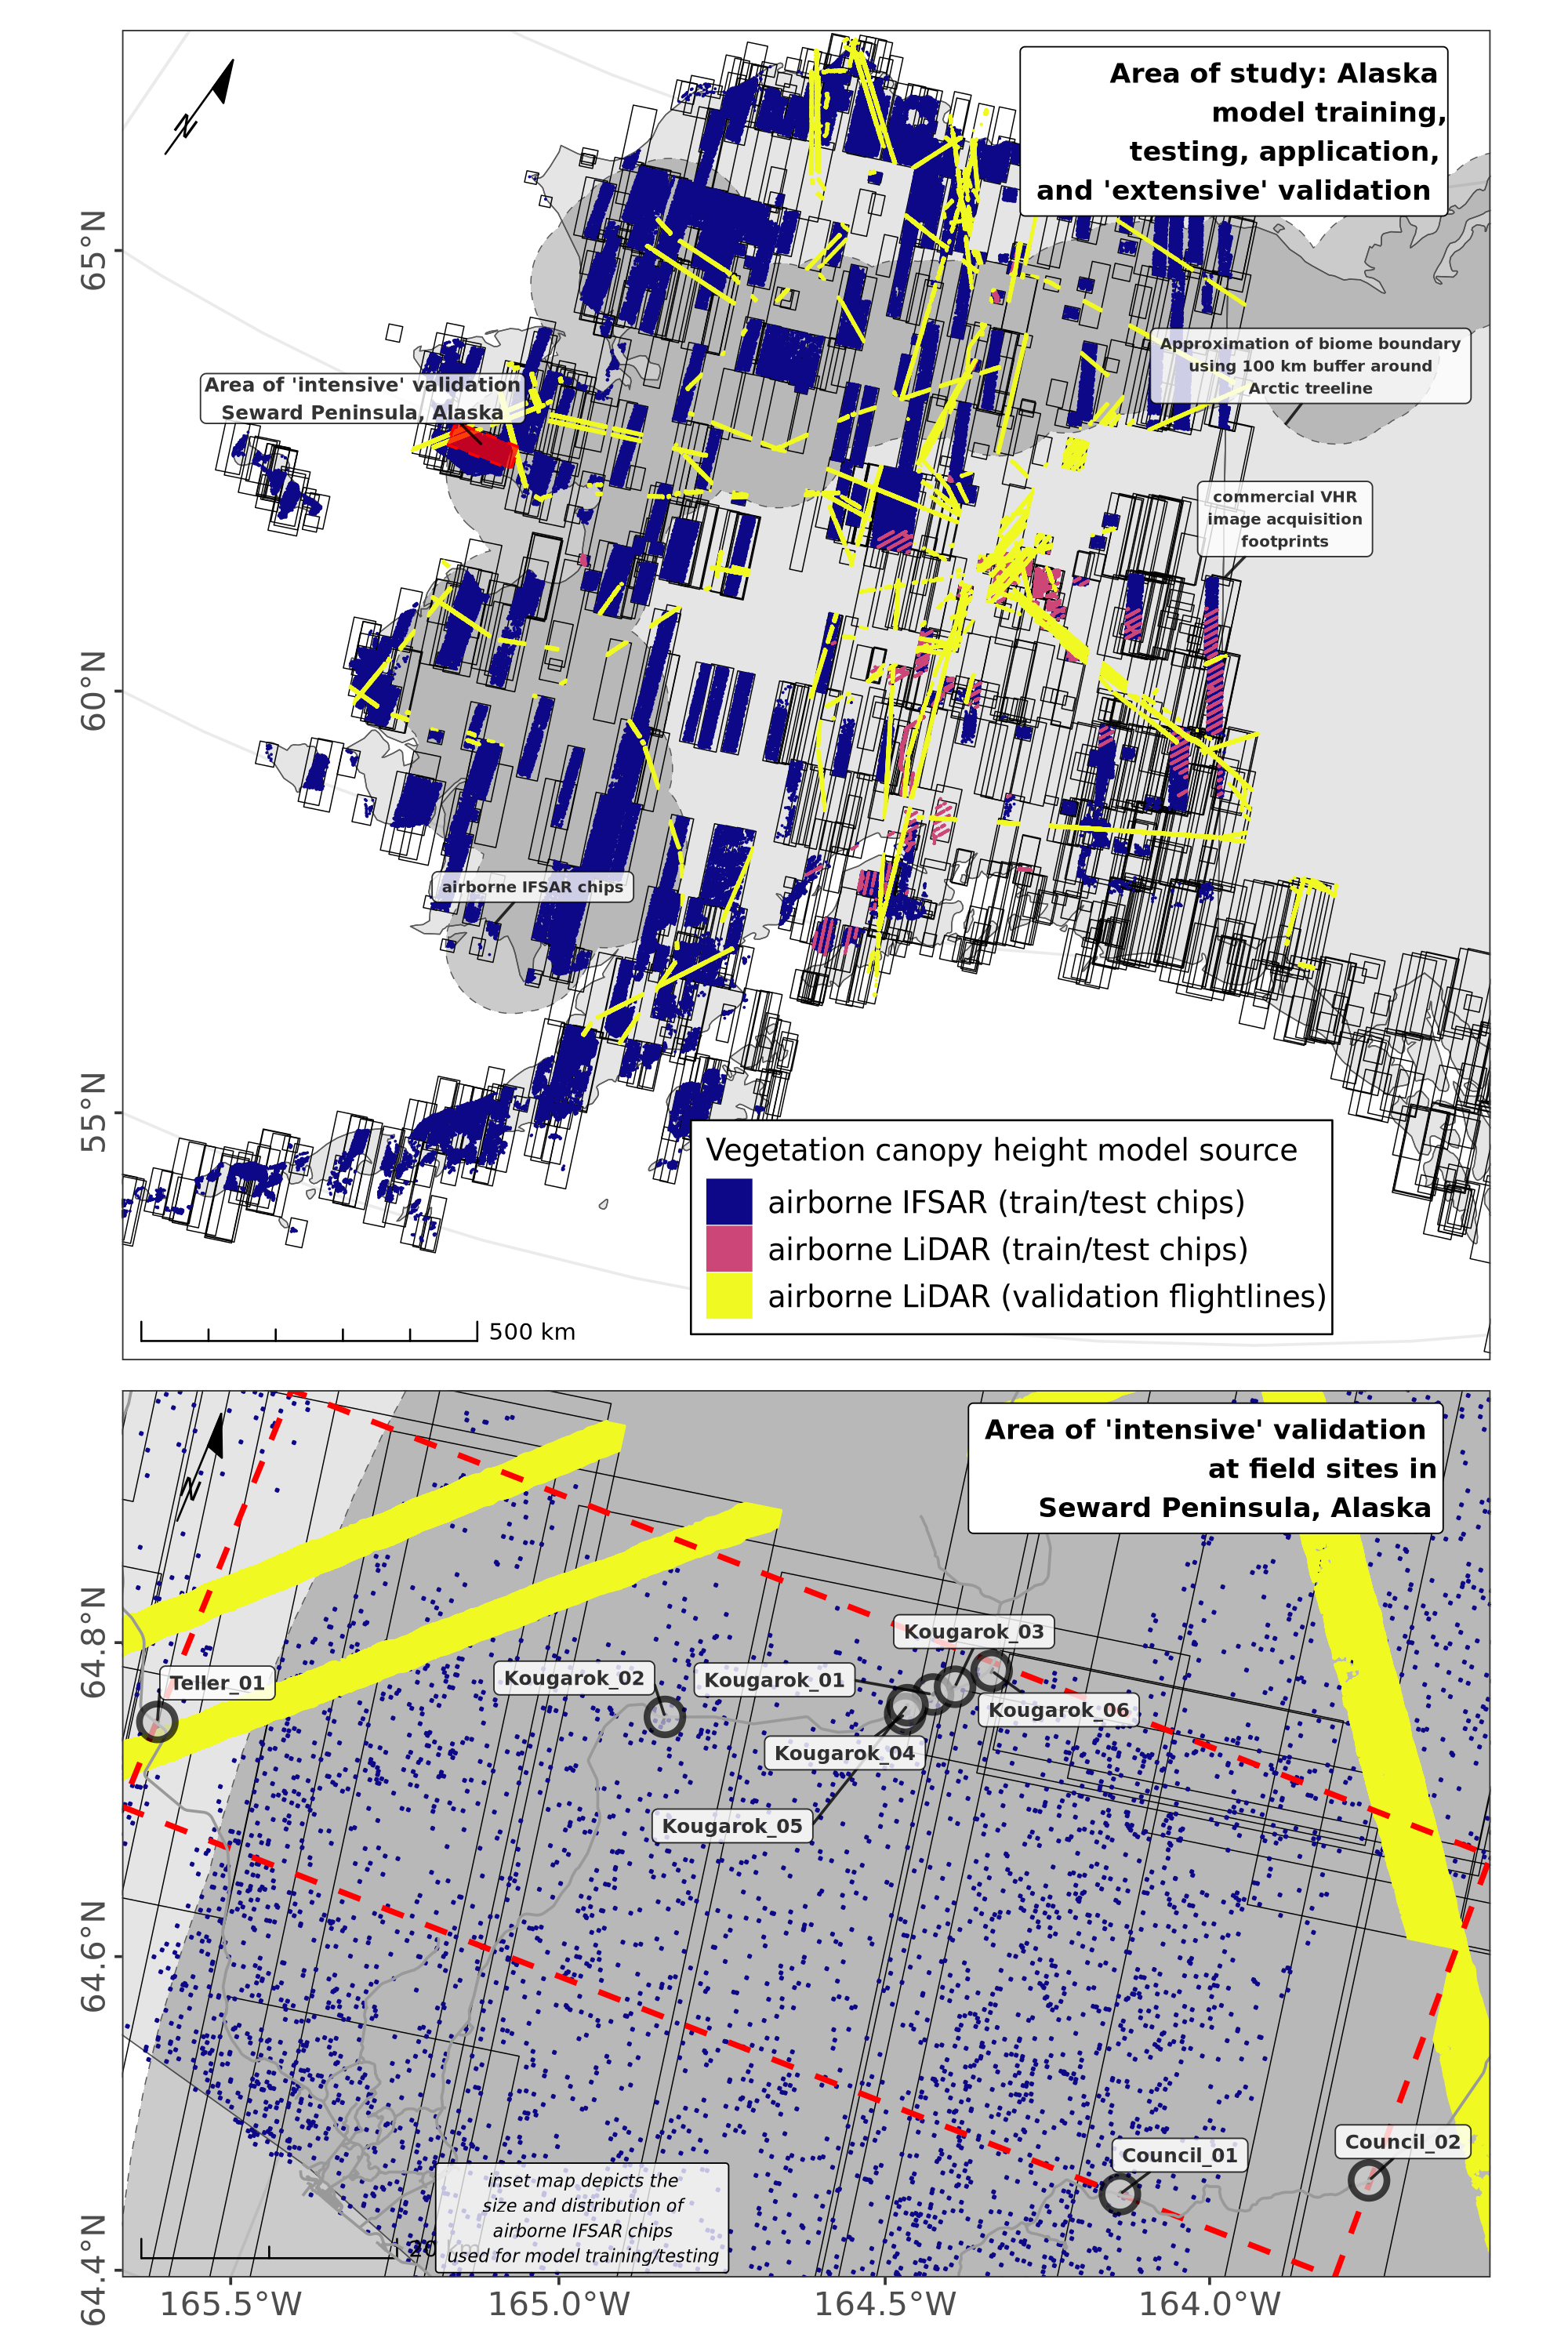

In [84]:
options(repr.plot.width = 8, repr.plot.height = 12, repr.plot.res = 250, warn=-1)

##################################
# BUILD INSET BOX ,  ANNOTATION, and PLOT
##################################
# Define zoom bbox (xmin, xmax, ymin, ymax)
inset_bbox <- c(xmin = -165, xmax = -164, ymin = 64.5, ymax = 65.0)
inset_bbox <- st_bbox(footprints_uav)

# Create rectangle polygon in WGS84
inset_rect <- st_as_sfc(st_bbox(inset_bbox, crs = 4326))

# Transform to your map's CRS
inset_rect_proj <- st_transform(inset_rect, crs = crs_canalb)

# Get bbox coordinates in projected CRS for inset limits
inset_bbox_proj <- st_bbox(inset_rect_proj)

# Convert to dataframe for ggplot
inset_rect_df <- st_sf(geometry = inset_rect_proj)
inset_rect_df$site_name = "Area of 'intensive' validation\nSeward Peninsula, Alaska"

# Calculate centroid of the zoom rectangle
inset_rect_centroid <- st_centroid(inset_rect_df)

# Extract coordinates
inset_coords <- st_coordinates(inset_rect_centroid)

# Add to dataframe
inset_rect_df$x_centroid <- inset_coords[, "X"]
inset_rect_df$y_centroid <- inset_coords[, "Y"]

##################################
# Create INSET (zoomed) map
##################################
# Create annotation data
inset_anno_df <- data.frame(
          x = Inf,
          y = Inf,
          label = "Area of 'intensive' validation\nat field sites in \nSeward Peninsula, Alaska"
        )

# Create annotation dataframe in lat/lon
inset_anno_geom_df <- data.frame(
  lon = c(-165),
  lat = c(64.55),
  label = c("inset map depicts the\nsize and distribution of\nairborne IFSAR chips\nused for model training/testing")
)

# Convert to sf object with WGS84 (EPSG:4326)
inset_anno_geom_sf <- st_as_sf(inset_anno_geom_df, coords = c("lon", "lat"), crs = 4326) %>% st_transform(crs = crs_canalb)

# Extract coordinates in projected CRS for ggplot
anno_coords <- st_coordinates(inset_anno_geom_sf)
inset_anno_geom_sf$x <- anno_coords[, "X"]
inset_anno_geom_sf$y <- anno_coords[, "Y"]

p_inset <- 
    map_overview +
            geom_sf(data = inset_rect_df, fill = NA, color = "red", linewidth = 1.0, linetype = 'dashed') +  # Projected box
            geom_sf(data = footprints_uav, color='black', fill='black') +
            geom_sf(data = sewpen_roads, color='gray60') +
            geom_sf(data = smry_sewpen_field_proj_median, color='black', shape=21, size=5, stroke = 1.75, fill='gray80', alpha=0.7) +
            coord_sf(xlim = c(inset_bbox_proj['xmin'], inset_bbox_proj['xmax']),
                   ylim = c(inset_bbox_proj['ymin'], inset_bbox_proj['ymax']),
                   crs = crs_canalb,  # Same CRS as main map
                   expand = FALSE) +
            # theme_bw() +
            theme(
            legend.position = "none"
            ) +
            geom_label(data = inset_anno_df, 
                     aes(x = x, y = y, label = label),
                     hjust = 1.1, vjust = 1.1, 
                     size = 3.5, fontface = "bold",
                     fill = "white", 
                     label.padding = unit(0.5, "lines")) +
            geom_sf_label(data = inset_anno_geom_sf, 
                     aes(x = x, y = y, label = label), alpha=0.75,
                     hjust = 0.5, vjust = 0.5, 
                     size = 2.25, fontface = "italic",
                     fill = "white", 
                     label.padding = unit(0.5, "lines"))

##################################
# Combine OVERVIEW with INSET
##################################
# Create annotation data
main_anno_df <- data.frame(
          x = Inf,
          y = Inf,
          label = "Area of study: Alaska\nmodel training,\ntesting, application,\nand 'extensive' validation"
        )

# Create annotation dataframe in lat/lon
main_anno_geom_df <- data.frame(
  lon = c(-141, -160.1, -139),
  lat = c(65, 59, 67),
  label = c("commercial VHR\nimage acquisition\nfootprints", 
            "airborne IFSAR chips",
           "Approximation of biome boundary\nusing 100 km buffer around\nArctic treeline")
)

# Convert to sf object with WGS84 (EPSG:4326)
main_anno_geom_sf <- st_as_sf(main_anno_geom_df, coords = c("lon", "lat"), crs = 4326) %>% st_transform(crs = crs_canalb)

# Extract coordinates in projected CRS for ggplot
anno_coords <- st_coordinates(main_anno_geom_sf)
main_anno_geom_sf$x <- anno_coords[, "X"]
main_anno_geom_sf$y <- anno_coords[, "Y"]

map_combined <- (
    map_overview + 
            geom_sf(data = inset_rect_df, fill = 'red', color = "red", alpha=0.75, linewidth = 0.5, linetype = 'dashed') +  # Projected box
            coord_sf(xlim=disp_win_coord[,'X'], ylim=disp_win_coord[,'Y'], crs=crs_canalb, expand=FALSE)  +

            geom_label(data = main_anno_df, 
                    aes(x = x, y = y, label = label),
                    hjust = 1.1, vjust = 1.1, 
                    size = 3.5, fontface = "bold",
                    fill = "white", 
                    label.padding = unit(0.5, "lines")) +
    
            geom_label_repel(data = inset_rect_df, 
                    aes(x = x_centroid, y = y_centroid, label = site_name),
                    hjust = 0.5, vjust = 0.5, 
                    fill = "white", 
                    nudge_x = -150000,      # Offset to the right (adjust for your CRS units)
                    nudge_y = 50000,      # Offset upward
                    size = 2.5, 
                    fontface = "bold",
                    fill = "white", 
                    alpha = 0.8,
                    box.padding = 0.5,
                    segment.color = "black",  # Line connecting label to point
                    segment.size = 0.5,
                    label.padding = unit(0.1, "lines")) +
    
            geom_label_repel(data = main_anno_geom_sf, 
                    aes(x = x, y = y, label = label),
                    nudge_x = 50000,      # Offset to the right (adjust for your CRS units)
                    nudge_y = 50000,      # Offset upward
                    size = 2, 
                    fontface = "bold",
                    fill = "white", 
                    alpha = 0.8,
                    box.padding = 0.5,
                    segment.color = "black",  # Line connecting label to point
                    segment.size = 0.5)
    ) / (
    p_inset +
            geom_label_repel(data = smry_sewpen_field_proj, 
                    aes(x = x_centroid, y = y_centroid, label = site),
                    nudge_x = 500,      # Offset to the right (adjust for your CRS units)
                    nudge_y = 500,      # Offset upward
                    size = 2.5, 
                    fontface = "bold",
                    fill = "white", 
                    alpha = 0.8,
                    box.padding = 0.5,
                    segment.color = "black",  # Line connecting label to point
                    segment.size = 0.5)
        )
            

print(map_combined)

In [86]:
OUTDIR

[1] "/projects/my-public-bucket/above_shrubs/paper_figs"

In [87]:
Sys.Date()

[1] "2026-02-04"

In [88]:
ggsave(paste0(OUTDIR, "/alaska_map_studyarea_dinov3_training_",Sys.Date(),".png"), map_combined, width = 8, height = 12, dpi = 250, bg='white')

In [27]:
## Put TTE on map?

In [28]:
raster_read_proj_convert <- function(fn, to_crs="EPSG:4326", BOREAL_MAP=TRUE, LYR=NA){
    
    raster_proj <- rast(fn)    
    r <- project(raster_proj, to_crs , method='cubic' )
    r[is.infinite(r), 'class'] <- NA
    # Convert raster to data frame
    r_df <- as.data.frame(r, xy = TRUE)
    
    if(BOREAL_MAP){
        names(r_df)[names(r_df) == 'lyr1'] <- 'prediction mean'
        names(r_df)[names(r_df) == 'sd']   <- 'prediction standard deviation'
        }
    if(!is.na(LYR)){
        names(r_df) <- c('x','y', LYR)
        }
    return (r_df)
    }

# Create the named classification vector
tte_classes <- c(
  "1" = "Sparse & Abrupt",
  "2" = "Sparse & Diffuse-rapid", 
  "3" = "Sparse & Diffuse-gradual    ",
  "4" = "Sparse & Uniform",
  "5" = "Open & Uniform",
  "6" = "Open & Diffuse-gradual    ",
  "7" = "Open & Diffuse-rapid", 
  "8" = "Open & Abrupt",
  "9" = "Intermediate & Closed    ",
  "10" = "Non-forest edge (dry)",
  "11" = "Non-forest edge (wet)"
)

# Create the color palette vector (matching your original colors)
tte_colors <- c(
  "1" = "#5255a3",   # Sparse & Abrupt
  "2" = "#1796a3",   # Sparse & Diffuse-rapid
  "3" = "#fdbf6f",   # Sparse & Diffuse-gradual
  "4" = "#ff7f00",   # Sparse & Uniform
  "5" = "#ffffbf",   # Open & Uniform
  "6" = "#d9ef8b",   # Open & Diffuse-gradual
  "7" = "#91cf60",   # Open & Diffuse-rapid
  "8" = "#1a9850",   # Open & Abrupt
  "9" = "#c4c4c4",   # Intermediate & Closed
  "10" = "#ff0000",  # Non-forest edge (dry)
  "11" = "#0000ff"   # Non-forest edge (wet)
)

In [ ]:
# r_df = raster_read_proj_convert('/projects/my-public-bucket/local_output/TTEmap_3000/TTEmap_3000_classification_mosaic.tif', 
#                                 to_crs=crs_canalb, BOREAL_MAP=FALSE, LYR='class') 
r_df = raster_read_proj_convert('/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_4809tiles_0p010000.tif', 
                                to_crs=crs_canalb, BOREAL_MAP=FALSE, LYR='class')

In [ ]:
r_df$class = round(r_df$class,0)
# Convert class values to factors with proper labels
r_df$class <- factor(r_df$class)
# Convert class values to factors with proper labels
r_df$class_factor <- factor(r_df$class, 
                           levels = names(tte_classes),
                           labels = tte_classes)



head(r_df)

In [ ]:
# # MERIT DEM 3000m
# dem_r = rast('/projects/my-public-bucket/local_output/MERIT_DEM_3000/MERIT_DEM_3000_mosaic.tif')
# hs_df = hs_dem(dem_r, crs_canalb)[[1]]

In [ ]:
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 300)


# Create the plot
map_overview_TTE = map_overview + 
    #geom_raster(data = hs_df, mapping = aes(x = x, y = y, alpha = hillshade-0.1),  show.legend=FALSE) +
    geom_raster(data = r_df, mapping = aes(x = x, y = y, fill = class)) +
    scale_fill_manual(values = tte_colors, labels = tte_classes,
                   name = "TTE forest structure pattern class",
                   na.value = "transparent") +
    guides(fill = guide_legend(
        nrow = 6,          # 2 rows to accommodate 11 classes in ~6 columns each
        ncol = 2,          # 6 columns
        byrow = FALSE,      # Fill by rows first
        title.position = "top",
        title.hjust = 0.5,
        label.position = "right",
        #override.aes = list(size = 3)  # Make legend keys more visible
    )) +
    theme(
        legend.position = c(0.98, 0.97),
        legend.justification = c("right", "top"),
        legend.direction = "horizontal",
        legend.title = element_text(size = 12
                                    #, face = "bold"
                                    , hjust = 0.5),
        legend.text = element_text(size = 8),
        #legend.key.size = unit(0.35, "cm"),
        legend.key.width = unit(0.35, "cm"),
        legend.key.height = unit(0.35, "cm"),
        legend.box = "horizontal",
        # # Increase spacing between legend items
        # legend.spacing.x = unit(5.75, "cm"),  # Horizontal spacing between items
        # legend.spacing.y = unit(0.01, "cm"),  # Vertical spacing between rows
        # Add overall margin to the legend
        #legend.margin = margin(t = 5, r = 5, b = 5, l = 5)
    )

map_overview_TTE

In [ ]:
ggsave(paste0(OUTDIR, "/alaska_map_TTE_dinov3_training_",Sys.Date(),".png"), map_overview_TTE, width = 9, height = 7, dpi = 250, bg='white')